In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO,
                    filename='model.log',
                    filemode='w',
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    force=True)



In [2]:
# cheking data
df = pd.read_csv(r'C:\Devesh ITV\Machine Learning\CandidateSelectionPredictionModel\data\resume_screening_dataset.csv')
df.sample(frac=1)

,candidate_id,age,gender,degree,specialization,university_tier,cgpa,years_experience,internships_count,projects_count,...,deep_learning_skill,communication_skill,leadership_skill,github_projects,kaggle_activity_score,hackathons_participated,expected_salary_lpa,location,employment_gap_months,selected
40043,CAND-040044,19,Male,MBA,Computer Science,Tier 3,9.01,0,2,0,...,4,4,4,1,3.9,2,4.8,Chandigarh,0,No
320,CAND-000321,33,Female,MBA,Data Science,Tier 3,9.19,12,1,4,...,8,7,5,1,5.7,2,26.3,Mumbai,0,No
21627,CAND-021628,32,Male,BCA,Mechanical,Tier 3,8.64,11,0,4,...,5,7,5,4,5.6,3,19.0,Bangalore,8,No
37704,CAND-037705,27,Female,BCA,Computer Science,Tier 2,7.30,4,0,3,...,3,6,6,4,7.1,3,10.1,Delhi,0,No
28536,CAND-028537,27,Male,B.Tech,Electrical,Tier 3,7.01,6,2,2,...,4,5,8,2,3.5,0,15.2,Kolkata,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34406,CAND-034407,32,Male,B.Com,Business Analytics,Tier 3,7.67,7,1,8,...,5,6,4,5,6.4,1,16.9,Bangalore,7,No
37769,CAND-037770,36,Male,B.E.,Computer Science,Tier 3,9.33,15,1,5,...,8,6,8,8,6.8,1,32.8,Lucknow,9,Yes
45187,CAND-045188,36,Male,B.Sc,Artificial Intelligence,Tier 3,7.98,14,2,8,...,7,7,6,3,5.8,2,26.4,Pune,9,Yes
15659,CAND-015660,26,Female,B.Tech,Artificial Intelligence,Tier 3,7.22,6,2,4,...,5,5,8,1,4.9,2,13.8,Hyderabad,0,No


In [3]:
# cheking info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   candidate_id             50000 non-null  str    
 1   age                      50000 non-null  int64  
 2   gender                   50000 non-null  str    
 3   degree                   50000 non-null  str    
 4   specialization           50000 non-null  str    
 5   university_tier          50000 non-null  str    
 6   cgpa                     50000 non-null  float64
 7   years_experience         50000 non-null  int64  
 8   internships_count        50000 non-null  int64  
 9   projects_count           50000 non-null  int64  
 10  certifications_count     50000 non-null  int64  
 11  python_skill             50000 non-null  int64  
 12  sql_skill                50000 non-null  int64  
 13  machine_learning_skill   50000 non-null  int64  
 14  deep_learning_skill      50000 no

In [4]:

categorical_data = df.select_dtypes(include='str')
numerical_data = df.select_dtypes(exclude='str')
categorical_data.columns,numerical_data.columns


(Index(['candidate_id', 'gender', 'degree', 'specialization', 'university_tier',
        'location', 'selected'],
       dtype='str'),
 Index(['age', 'cgpa', 'years_experience', 'internships_count',
        'projects_count', 'certifications_count', 'python_skill', 'sql_skill',
        'machine_learning_skill', 'deep_learning_skill', 'communication_skill',
        'leadership_skill', 'github_projects', 'kaggle_activity_score',
        'hackathons_participated', 'expected_salary_lpa',
        'employment_gap_months'],
       dtype='str'))

In [5]:
# cheking Duplicated
df.duplicated().sum()

np.int64(0)

In [6]:
# cheking null
df.isnull().sum()

candidate_id               0
age                        0
gender                     0
degree                     0
specialization             0
university_tier            0
cgpa                       0
years_experience           0
internships_count          0
projects_count             0
certifications_count       0
python_skill               0
sql_skill                  0
machine_learning_skill     0
deep_learning_skill        0
communication_skill        0
leadership_skill           0
github_projects            0
kaggle_activity_score      0
hackathons_participated    0
expected_salary_lpa        0
location                   0
employment_gap_months      0
selected                   0
dtype: int64

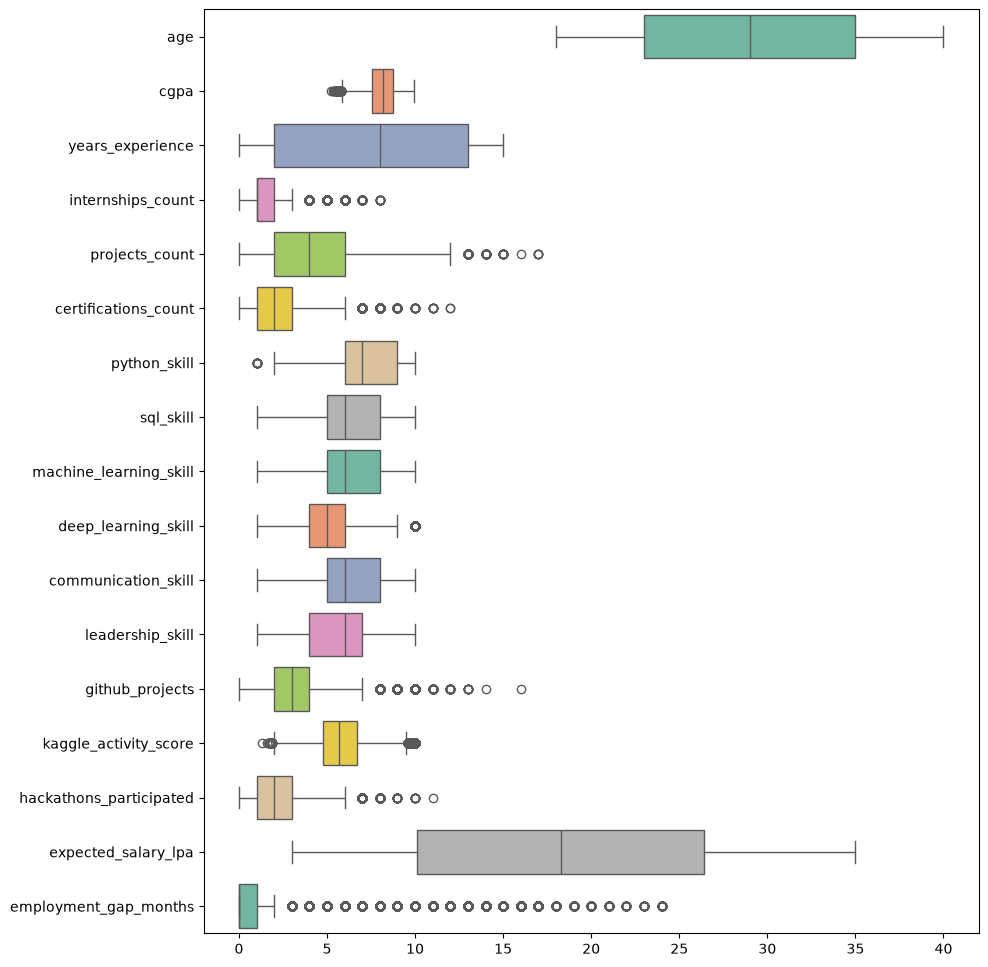

In [7]:
# checking outliers using boxplot

plt.figure(figsize=(10,12))
sns.boxplot(data=df,orient='h',palette='Set2')
plt.grid(False)
plt.show()

In [8]:
# checking descriptive stats
from collections import OrderedDict

stats=[]

for i in numerical_data.columns: # type: ignore
    numerical_stats=OrderedDict({
        'Feature':i,
        'Count':numerical_data[i].count(),
        'Mean':numerical_data[i].mean(),
        'Median':numerical_data[i].median(),
        'Max':numerical_data[i].max(),
        'Min':numerical_data[i].min(),
        'Q1':numerical_data[i].quantile(0.25),
        'Q3':numerical_data[i].quantile(0.75),
        'IQR':numerical_data[i].quantile(0.75)-numerical_data[i].quantile(0.25),
        'Standard Deviation':numerical_data[i].std(),
        'Skewness':numerical_data[i].skew(),
        'Kurtosis':numerical_data[i].kurt()
        
    })
    stats.append(numerical_stats)
report=pd.DataFrame(stats)
report


,Feature,Count,Mean,Median,Max,Min,Q1,Q3,IQR,Standard Deviation,Skewness,Kurtosis
0,age,50000,29.086480,29.00,40.00,18.00,23.00,35.00,12.00,6.629926,-0.011904,-1.203719
1,cgpa,50000,8.124736,8.18,9.94,5.23,7.57,8.73,1.16,0.806433,-0.312981,-0.395465
2,years_experience,50000,7.560560,8.00,15.00,0.00,2.00,13.00,11.00,5.648703,-0.017260,-1.501766
3,internships_count,50000,1.442200,1.00,8.00,0.00,1.00,2.00,1.00,1.223392,0.868927,0.775589
4,projects_count,50000,3.896180,4.00,17.00,0.00,2.00,6.00,4.00,2.618629,0.705846,0.204516
5,certifications_count,50000,1.937500,2.00,12.00,0.00,1.00,3.00,2.00,1.632215,0.956618,0.943609
6,python_skill,50000,7.372560,7.00,10.00,1.00,6.00,9.00,3.00,1.840040,-0.293521,-0.665581
7,sql_skill,50000,6.394680,6.00,10.00,1.00,5.00,8.00,3.00,1.733173,-0.060510,-0.411724
8,machine_learning_skill,50000,6.396740,6.00,10.00,1.00,5.00,8.00,3.00,1.847952,-0.097356,-0.491175
9,deep_learning_skill,50000,5.216380,5.00,10.00,1.00,4.00,6.00,2.00,1.696165,-0.005778,-0.287909


In [9]:
# stats of categorical
df.describe(include='str').T # type: ignore

,count,unique,top,freq
candidate_id,50000,50000,CAND-000001,1
gender,50000,3,Male,27529
degree,50000,11,B.Tech,12577
specialization,50000,16,Computer Science,8917
university_tier,50000,3,Tier 3,24932
location,50000,20,Bangalore,8923
selected,50000,2,No,30000


In [10]:
# removing unwanted columns
df.drop(columns=['candidate_id'],inplace=True)

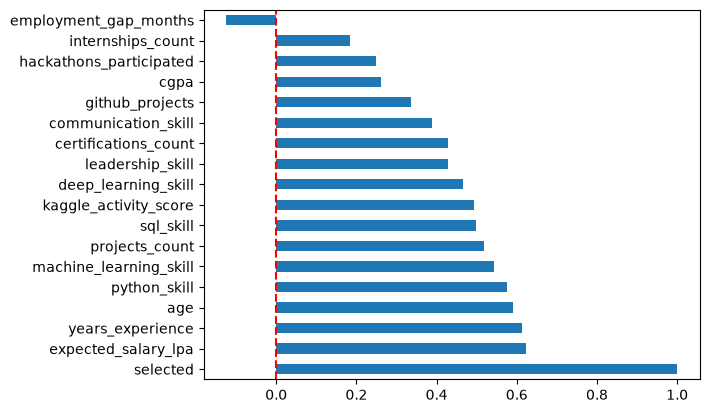

In [11]:
# encoding Target col
df['selected'] = df['selected'].map({'Yes':1,'No':0})

df.select_dtypes(exclude='str').corr()['selected'].sort_values(ascending=False).plot(kind='barh')
plt.axvline(0,linestyle='--',color='r')
plt.show()

In [12]:
# # chelking balance of target column
# df['selected'].plot(kind='pie',autopct='%0.2f')
# plt.show

In [13]:
# encoding categorical
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
# le=OneHotEncoder(handle_unknown="ignore", drop="first",sparse_output=False)

for i in df.select_dtypes(include='str').columns :
    df[i] = le.fit_transform(df[i])
    

In [14]:
# splitting data into target and input features
X = df.drop(columns=['selected'])
y = df['selected']

In [15]:
# Splitting into Seen and Unseen (Training and Testing)
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,                                              
                                                 random_state=1)

X_train.shape, X_test.shape,y_train.shape,y_test.shape

((35000, 22), (15000, 22), (35000,), (15000,))

In [16]:
# balancing the target colum using Smote
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train,y_train = sm.fit_resample(X_train,y_train) # type: ignore



In [17]:
# Scaling Data
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

X_train.max(), X_train.min()

(np.float64(1.0000000000000002), np.float64(0.0))

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train) # type: ignore
X_test = pca.transform(X_test)

X_train.shape, X_test.shape


((41856, 16), (15000, 16))

In [19]:
# cheking best model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

models = {
    'Logistic Regression':LogisticRegression(),
    'Decision Tree Classifier':DecisionTreeClassifier(),
    'Random Forest Classifier':RandomForestClassifier(),
    'Extra Trees Classifier':ExtraTreesClassifier(),
    # 'KNeighborsClassifier':KNeighborsClassifier(n_neighbors=5)
    }

for model_name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    r2_score_test=model.score(X_test,y_test)
    r2_score_train=model.score(X_train,y_train)
    
    
    print(f'{model_name} Training R2 score is {r2_score_train}')
    print(f'{model_name} Test R2 score is {r2_score_test}')
    print(classification_report(y_test,y_pred))
    print()
    print()
   
   


Logistic Regression Training R2 score is 0.8659451452599388
Logistic Regression Test R2 score is 0.8701333333333333
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      9072
           1       0.81      0.88      0.84      5928

    accuracy                           0.87     15000
   macro avg       0.86      0.87      0.87     15000
weighted avg       0.87      0.87      0.87     15000



Decision Tree Classifier Training R2 score is 1.0
Decision Tree Classifier Test R2 score is 0.8015333333333333
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      9072
           1       0.73      0.79      0.76      5928

    accuracy                           0.80     15000
   macro avg       0.79      0.80      0.80     15000
weighted avg       0.81      0.80      0.80     15000



Random Forest Classifier Training R2 score is 1.0
Random Forest Classifier Test R2 score is 0.8624666666666667
    

In [20]:
from flaml.automl.automl import AutoML

# Initialize an AutoML instance
automl = AutoML()
# Specify automl goal and constraint
automl_settings = {
    "time_budget": 20,  # in seconds
    "metric": "accuracy",
    "task": "classification"
}
# Train with labeled input data
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)
# Predict
print(automl.predict_proba(X_train))
# Print the best model
print(automl.model.estimator)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))


[flaml.automl.logger: 08-13 15:27:47] {2375} INFO - task = classification
[flaml.automl.logger: 08-13 15:27:47] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 08-13 15:27:47] {2489} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 08-13 15:27:47] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 08-13 15:27:47] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 08-13 15:27:47] {3046} INFO - Estimated sufficient time budget=1026s. Estimated necessary time budget=24s.
[flaml.automl.logger: 08-13 15:27:47] {3097} INFO -  at 0.2s,	estimator lgbm's best error=1.8251e-01,	best estimator lgbm's best error=1.8251e-01
[flaml.automl.logger: 08-13 15:27:47] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 08-13 15:27:47] {3097} INFO -  at 0.3s,	estimator lgbm's best error=1.8251e-01,	best estimator lgbm's best error=1.8251e-01
[flaml